In [1]:
import json
import os
import csv
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
REPO_ROOT = Path.cwd().resolve().parent
PROCESSED_ROOT = REPO_ROOT / "data" / "processed" / "peer"

In [3]:
# import datasets as dataframes for each of the 2 tasks
def load_datasets(task="localization", split="train"):
    with open(f'{PROCESSED_ROOT}/{task}/{split}.csv', 'r') as f:
        data = pd.read_csv(f)
    return data.drop(columns=["idx", "dataset", "split"])

localization_dfs = {
    "train": load_datasets(task="localization", split="train"),
    "test": load_datasets(task="localization", split="test"),
    "valid": load_datasets(task="localization", split="valid"),
}

solubility_dfs = {
    "train": load_datasets(task="solubility", split="train"),
    "test": load_datasets(task="solubility", split="test"),
    "valid": load_datasets(task="solubility", split="valid"),
}

In [4]:
localization_dfs['train'].head()

,sequence,label
0,MEFRGSGATAVEQHLLQSETPGKNGLQATSSDQVGRTLRWFTTVVL...,0
1,MKNSTAASSRWTKSRLSHFFPSYTNSSGMGAASTDQSSTQGEELHH...,0
2,MKMASSLAFLLLNFHVSLLLVQLLTPCSAQFSVLGPSGPILAMVGE...,0
3,MDHSAEKAAANAEVPQELLEEMLWYFRAEDAAPWNYSILVLAVLVV...,0
4,MIPCRAVLTFARCLIRRKIVTLDSLEDSKLCRCLTTVDLIALGVGS...,0


Start by looking at label distributions

In [5]:
localization_dfs['train']["label"].value_counts()

label
6    2426
1    1635
9    1185
5     906
0     800
2     516
8     453
3     214
4     192
7      93
Name: count, dtype: int64

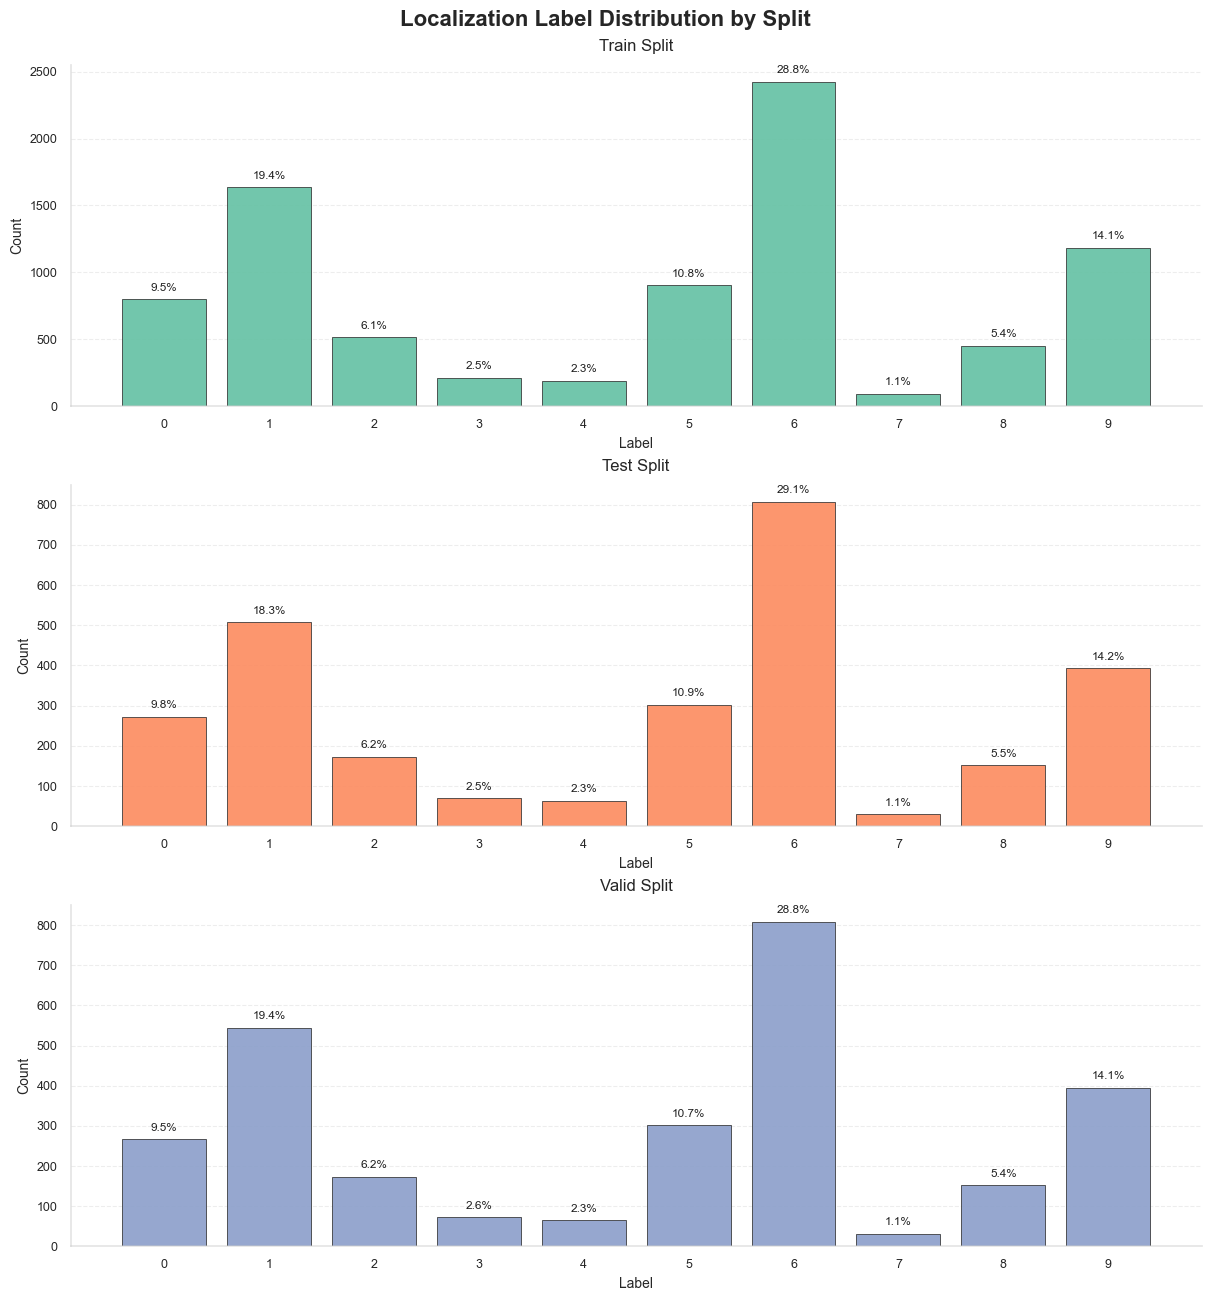


Localization imbalance diagnostics
- train: majority=6 (2426, 28.8%), minority=7 (93), max/min ratio=26.09
- test: majority=6 (808, 29.1%), minority=7 (30), max/min ratio=26.93
- valid: majority=6 (809, 28.8%), minority=7 (31), max/min ratio=26.10


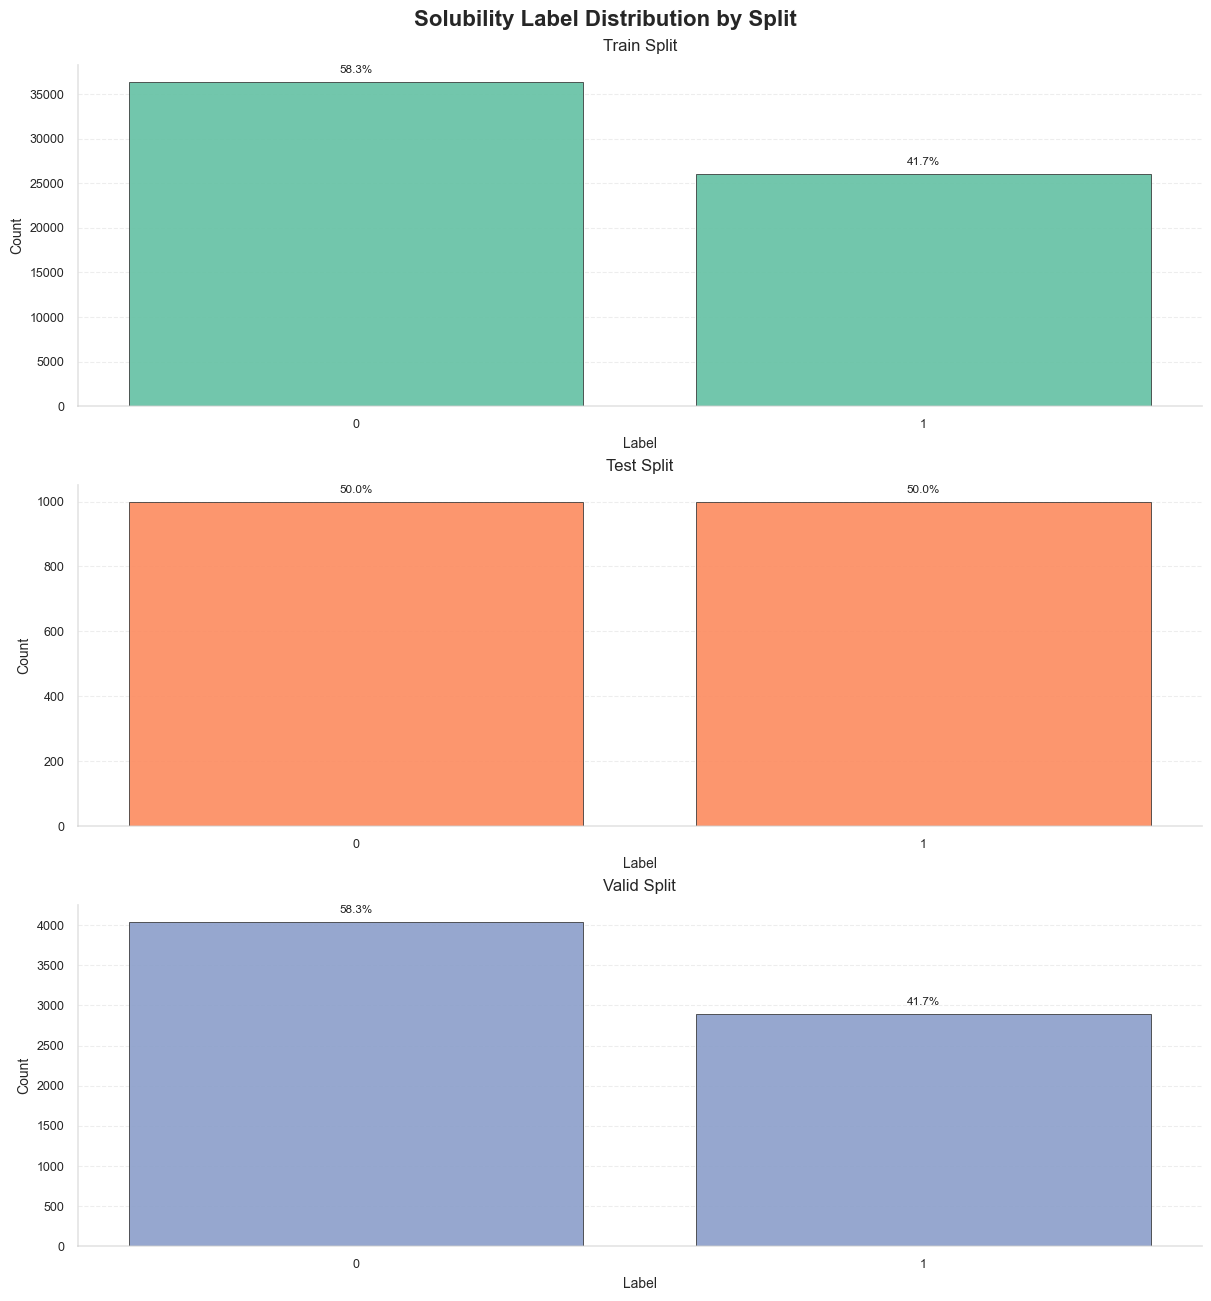


Solubility imbalance diagnostics
- train: majority=0 (36403, 58.3%), minority=1 (26075), max/min ratio=1.40
- test: majority=1 (1000, 50.0%), minority=0 (999), max/min ratio=1.00
- valid: majority=0 (4045, 58.3%), minority=1 (2897), max/min ratio=1.40


In [15]:
def plot_label_distribution(task_name, dfs_by_split):
    sns.set_theme(style="whitegrid", context="notebook")

    splits = list(dfs_by_split.keys())
    n_splits = len(splits)

    # One subplot per split so each split has its own label distribution chart
    fig, axes = plt.subplots(
        n_splits,
        1,
        figsize=(12, 4.2 * n_splits),
        sharex=False,
        constrained_layout=True,
    )
    if n_splits == 1:
        axes = [axes]

    fig.suptitle(
        f"{task_name.title()} Label Distribution by Split",
        fontsize=16,
        fontweight="bold",
        y=1.02,
    )

    count_by_split = {}
    split_colors = dict(zip(splits, sns.color_palette("Set2", n_colors=n_splits)))

    for ax, split in zip(axes, splits):
        split_counts = dfs_by_split[split]["label"].value_counts(dropna=False).sort_index()
        count_by_split[split] = split_counts

        labels = split_counts.index.astype(str)
        counts = split_counts.values
        pct = (split_counts / split_counts.sum()) * 100

        bars = ax.bar(
            labels,
            counts,
            color=split_colors[split],
            edgecolor="#2f2f2f",
            linewidth=0.6,
            alpha=0.92,
        )

        ax.set_title(f"{split.title()} Split", fontsize=12, pad=10)
        ax.set_xlabel("Label", fontsize=10)
        ax.set_ylabel("Count", fontsize=10)
        ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.35)
        ax.grid(axis="x", visible=False)
        ax.tick_params(axis="x", rotation=0, labelsize=9)
        ax.tick_params(axis="y", labelsize=9)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_alpha(0.5)
        ax.spines["bottom"].set_alpha(0.5)

        max_count = max(counts) if len(counts) > 0 else 0
        offset = max(1, int(max_count * 0.02))

        # Annotate bars with percentage for fast imbalance inspection
        for bar, c, p in zip(bars, counts, pct.values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                c + offset,
                f"{p:.1f}%",
                ha="center",
                va="bottom",
                fontsize=8.5,
                color="#1f1f1f",
            )

    plt.show()

    # Quick imbalance diagnostics
    print(f"\n{task_name.title()} imbalance diagnostics")
    for split, split_counts in count_by_split.items():
        nonzero = split_counts[split_counts > 0]
        if len(nonzero) == 0:
            print(f"- {split}: no labels found")
            continue

        majority = nonzero.max()
        minority = nonzero.min()
        majority_label = nonzero.idxmax()
        minority_label = nonzero.idxmin()
        ratio = majority / minority if minority > 0 else float("inf")
        majority_pct = (majority / nonzero.sum()) * 100

        print(
            f"- {split}: majority={majority_label} ({majority}, {majority_pct:.1f}%), "
            f"minority={minority_label} ({minority}), max/min ratio={ratio:.2f}"
        )

# Run for both tasks
plot_label_distribution("localization", localization_dfs)
plot_label_distribution("solubility", solubility_dfs)

Plots above show a pretty significant class imbalance for localization, but not terrible for solubility.

Localization:
- Seems to be stratefied, meaning that the proportions of each label are identical across all splits
- Class 6 has the most by far
- Class 7 is the smallest by far

Solubility:
- Proportions are not as close across all splits
- Class 0 has a slight edge in percentage for train and val split
- For test set, it seems to be about 50/50

Next I want to look into amino acid frequencies with respect to each label

In [17]:
from collections import Counter

def mean_aa_counts_by_label(dfs_by_split, task_name, use_split='train'):
    if use_split == 'all':
        df = pd.concat(dfs_by_split.values(), ignore_index=True)
    else:
        df = dfs_by_split[use_split].copy()

    # Count amino acids per sequence, then average counts within each label.
    seq_counts = df['sequence'].fillna('').astype(str).str.upper().apply(
        lambda s: Counter(ch for ch in s if 'A' <= ch <= 'Z')
    )
    aa_counts_df = pd.DataFrame(seq_counts.tolist()).fillna(0)

    mean_counts = (
        aa_counts_df.groupby(df['label'])
        .mean()
        .sort_index()
    )

    # Sort amino acids by overall abundance to make the heatmap easier to read.
    aa_order = mean_counts.mean(axis=0).sort_values(ascending=False).index
    mean_counts = mean_counts.loc[:, aa_order]

    display(mean_counts.round(2))

    plt.figure(figsize=(max(10, 0.7 * len(mean_counts.columns)), max(4, 0.7 * len(mean_counts.index))))
    sns.heatmap(mean_counts, cmap='YlGnBu', annot=True, fmt='.2f', cbar_kws={'label': 'mean count per protein'})
    plt.title(f"{task_name.title()} ({use_split}) - Mean Amino Acid Count per Label")
    plt.xlabel('Amino acid')
    plt.ylabel('Label')
    plt.tight_layout()
    plt.show()

    return mean_counts


,L,S,A,V,G,E,K,I,T,R,...,N,Q,Y,M,H,C,W,X,U,B
label,,,,,,,,,,,,,,,,,,,,,
0,59.12,46.87,39.35,38.09,38.04,29.37,26.40,32.12,31.88,26.17,...,23.47,19.77,17.83,13.47,11.84,12.06,8.27,0.00,0.00,0.0
1,50.77,46.11,36.26,31.68,31.46,40.31,35.47,27.47,28.31,29.09,...,24.97,24.59,15.14,11.67,12.90,8.61,5.25,0.00,0.00,0.0
2,51.57,34.92,30.25,30.19,27.49,25.89,24.75,26.55,24.51,21.61,...,18.31,16.06,17.03,11.08,11.19,7.58,8.16,0.00,0.00,0.0
3,51.85,39.62,31.34,30.71,26.68,32.46,29.87,27.99,25.27,24.90,...,21.36,20.61,16.28,11.97,11.08,8.01,7.25,0.00,0.00,0.0
4,54.29,41.30,33.56,34.44,32.77,26.99,24.86,33.06,27.26,21.24,...,23.43,17.27,18.26,11.99,10.79,8.16,7.56,0.00,0.00,0.0
5,38.38,28.87,28.08,25.11,25.26,23.53,25.84,21.09,20.14,21.85,...,16.09,14.73,11.18,8.97,8.99,5.60,4.13,0.00,0.00,0.0
6,47.09,49.69,35.21,29.00,31.58,41.00,37.94,24.18,27.71,31.29,...,24.70,26.16,13.91,11.52,13.70,9.08,4.92,0.00,0.00,0.0
7,45.39,35.08,36.67,32.40,32.82,26.38,27.66,25.71,24.58,24.82,...,17.73,16.57,14.37,10.43,10.11,6.69,5.69,0.00,0.00,0.0
8,41.28,37.94,32.71,31.23,30.14,28.32,25.78,23.05,22.32,23.76,...,16.67,13.58,11.27,9.75,7.87,6.04,4.74,0.00,0.00,0.0


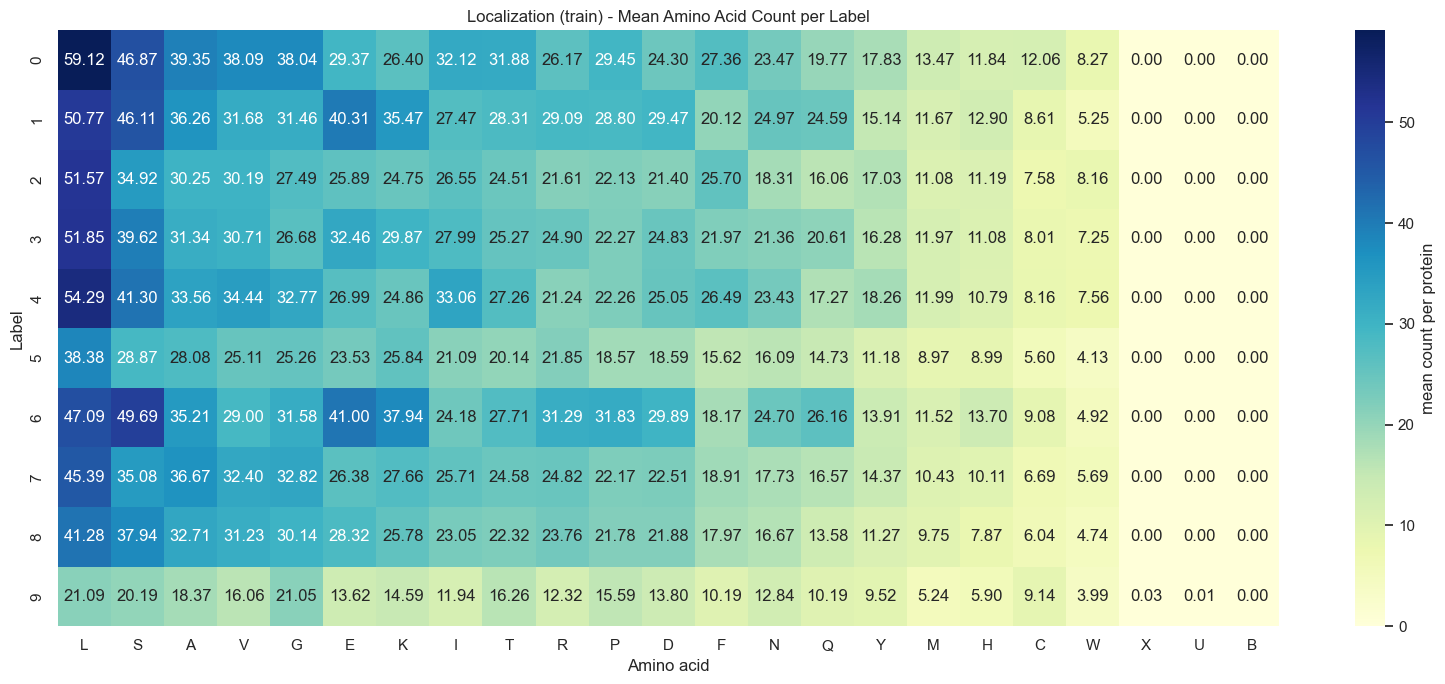

In [18]:
loc_mean_counts = mean_aa_counts_by_label(localization_dfs, 'localization', use_split='train')

Analyze above
- Seems like there is a decent amount of variance between each of the classes. Could mean that high frequency of certain amino acids could yield significant hints towards data

- B is weird, not an amino acid but found (granted very rarely) in the dataset
- X is also very weird. I presume that it represents a missing amino acid within a sequence

,L,A,E,G,V,S,K,D,I,R,T,P,N,F,Q,H,Y,M,C,W
label,,,,,,,,,,,,,,,,,,,,
0,28.70,24.41,21.09,20.31,19.76,19.39,17.60,17.60,17.95,17.35,15.72,13.50,12.54,11.81,11.92,10.24,9.99,7.69,3.95,3.47
1,27.04,23.16,21.18,20.27,19.61,18.00,17.33,16.64,16.27,15.78,14.80,13.33,11.54,10.99,10.84,9.06,9.23,6.76,3.65,3.36


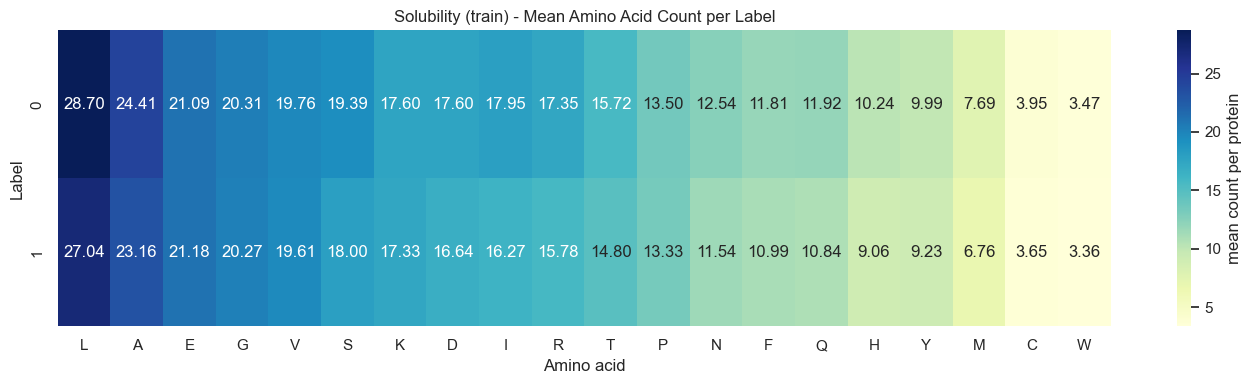

In [19]:
sol_mean_counts = mean_aa_counts_by_label(solubility_dfs, 'solubility', use_split='train')

Solubility heatmap analysis:
- Seems like the differences between the 2 classes aren't very significant

Next we want to look into the lengths of each of the sequences, and see what we are looking at there.
- What is the distribution of length for each of the sequences? Can we get a visualization of that?